# Vol 20 — Surface Dynamics, Forecasting & Hedging Decisions

**問い:** 予測誤差の小ささは、leakage-freeな下流ヘッジ改善につながるか。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

purged walk-forwardとtrain-only scaler/PCAを固定し、persistence・EWMA・HAR ridge・PCA ridge challengerを比較する。最後にsurrogate→calibration→forecast→hedgeをcommon pathsで評価し、Phase-1 policy未提供時は未評価と明記する。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'forecast_paths.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 20
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=20 digest=1e3f75aa33b50bda arrays=155


In [2]:
model_order = ['persistence', 'ewma', 'har_ridge', 'pca_ridge_challenger']
strategy_order = manifest['metrics']['end_to_end']['strategy_order']
data.update({
    'test_row': data['walk_forward_test_row'],
    'actual_variance': data['walk_forward_actual'],
    'har_ridge_prediction': data['walk_forward_prediction_har_ridge'],
    'pca_ridge_prediction': data['walk_forward_prediction_challenger'],
    'model_names': np.asarray(model_order),
    'rmse': np.asarray([manifest['metrics']['walk_forward']['models'][name]['rmse'] for name in model_order]),
    'qlike': np.asarray([manifest['metrics']['walk_forward']['models'][name]['qlike'] for name in model_order]),
    'hedge_names': np.asarray(strategy_order),
    'hedge_pnl': data['e2e_hedge_pnl'],
    'cvar95': np.asarray([manifest['metrics']['end_to_end']['strategy_metrics'][name]['cvar95'] for name in strategy_order]),
    'turnover': np.asarray([manifest['metrics']['end_to_end']['strategy_metrics'][name]['turnover'] for name in strategy_order]),
})

## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [3]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

array_fingerprint: sha256:5e7a948e2c30ee314c85a1b26a45a16ef882ae52d09ce842d1b2f9b12e6594ae
array_schema: {'attention_importance': {'dtype': '<f4', 'shape': [22], 'unit': 'dimensionless'}, 'attention_lag': {'dtype': '<i8', 'shape': [22], 'unit': 'dimensionless'}, 'dynamics_features': {'dtype': '<f8', 'shape': [393, 7], 'unit': 'dimensionless'}, 'dynamics_returns': {'dtype': '<f8', 'shape': [420], 'unit': 'log_return'}, 'dynamics_source_time_index': {'dtype': '<i8', 'shape': [393], 'unit': 'dimensionless'}, 'dynamics_target_variance': {'dtype': '<f8', 'shape': [393], 'unit': 'future_variance_sum'}, 'e2e_calibrated_parameters': {'dtype': '<f8', 'shape': [3], 'unit': 'dimensionless'}, 'e2e_hedge_pnl': {'dtype': '<f8', 'shape': [4, 512], 'unit': 'currency_units'}, 'e2e_hedge_turnover': {'dtype': '<f8', 'shape': [4, 512], 'unit': 'currency_notional'}, 'e2e_path_ids': {'dtype': '<i8', 'shape': [512], 'unit': 'dimensionless'}, 'e2e_true_parameters': {'dtype': '<f8', 'shape': [3], 'unit': 'dime

## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [4]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS purged_walk_forward 8 > horizon + embargo
PASS train_only_preprocessing train_only_each_fold == train_only_each_fold
PASS forecast_target_families 3 1/5/21-day log-RV, future-RV, and 3D surface-latent targets
PASS forecast_model_ladder 4 contains four required models
PASS horizon_model_ladders 10 all ten models share purged train-only folds at 1/5/21 days
PASS fold_preprocessing_evidence 3 stored scaler/PCA/sequence fits and purge bounds for every horizon
PASS block_bootstrap_intervals True ordered for every model
PASS horizon_regime_intervals 3 QLIKE/RMSE/MAE and paired Log-HAR comparisons have ordered block CIs
PASS explainability_diagnostics 4 four finite diagnostics explicitly marked non-causal
PASS common_path_hedge 512 P&L and turnover share all path ids
PASS economic_comparison_controls 512 common paths/premium/costs and explicit no-trade region
PASS phase1_policy_status not_evaluated explicit evaluated/not_evaluated state


## walk-forward RV forecast

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

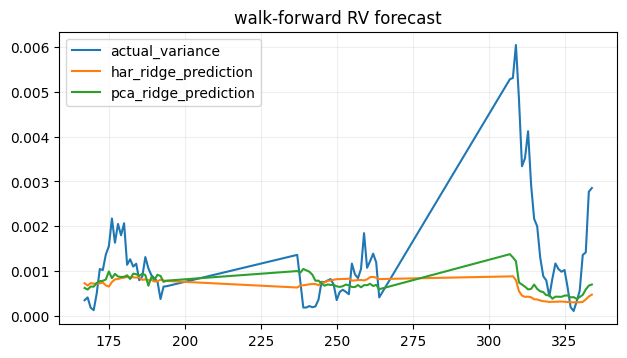

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("walk-forward RV forecast")
ax.plot(data["test_row"], data["actual_variance"], label="actual_variance")
ax.plot(data["test_row"], data["har_ridge_prediction"], label="har_ridge_prediction")
ax.plot(data["test_row"], data["pca_ridge_prediction"], label="pca_ridge_prediction")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## forecast metricとblock-bootstrap CI

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


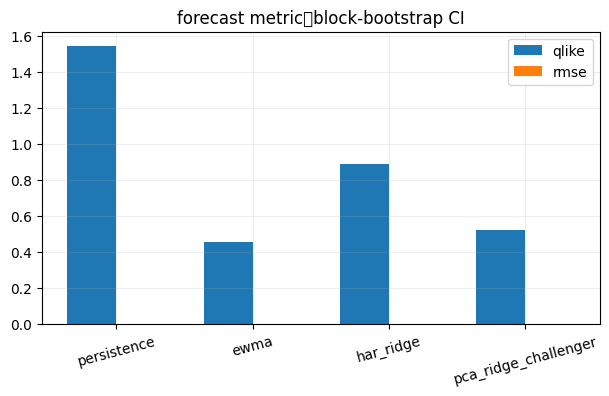

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("forecast metricとblock-bootstrap CI")
x = np.arange(len(data["model_names"]))
ax.bar(x - .18, data["qlike"], width=.36, label="qlike")
ax.bar(x + .18, data["rmse"], width=.36, label="rmse")
ax.set_xticks(x, data["model_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## common-path hedge P&L

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

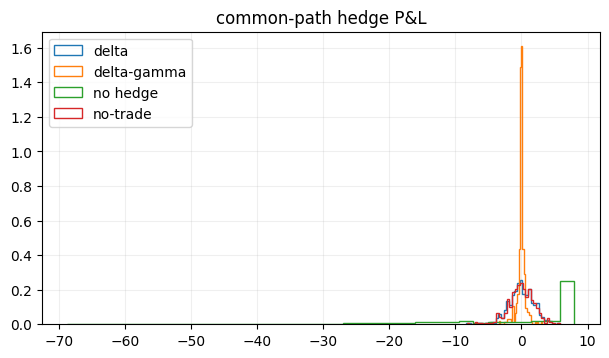

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("common-path hedge P&L")
for i, label in enumerate(data["hedge_names"]):
    ax.hist(data["hedge_pnl"][i], bins=35, density=True, histtype="step", label=str(label))
ax.legend()
ax.grid(alpha=.2)
plt.show()

## CVaRとturnover

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


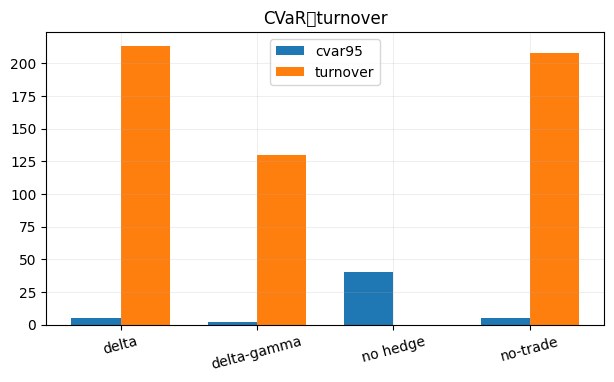

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("CVaRとturnover")
x = np.arange(len(data["hedge_names"]))
ax.bar(x - .18, data["cvar95"], width=.36, label="cvar95")
ax.bar(x + .18, data["turnover"], width=.36, label="turnover")
ax.set_xticks(x, data["hedge_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [9]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Corsi (2009), HAR-RV; Patton (2011), volatility forecast comparison.

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。